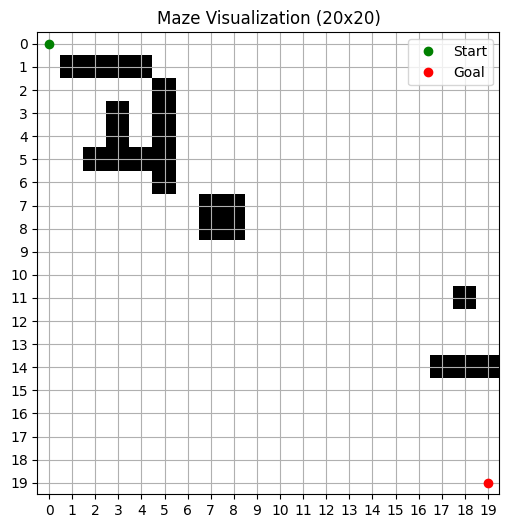

In [5]:
import numpy as np
import matplotlib.pyplot as plt

maze_size = 20 #changed from 10 to 20

maze = np.zeros((maze_size, maze_size), dtype=int)

walls = [
    (1,1),(1,2),(1,3),(1,4),
    (2,5),(3,5),(4,5),(5,5),(6,5),
    (5,2),(5,3),(5,4),
    (3,3),(4,3),
    (7,7),(7,8),(8,7),(8,8),
    (11,18),(14,17),(14,18),(14,19)
]

for r, c in walls:
    maze[r, c] = 1

start = (0, 0)
goal = (maze_size - 1, maze_size - 1)

plt.figure(figsize=(6, 6))
plt.imshow(maze, cmap='binary')

plt.xticks(np.arange(maze_size))
plt.yticks(np.arange(maze_size))
plt.grid(True)

# plot uses (col, row)
plt.plot(start[1], start[0], 'go', label='Start')
plt.plot(goal[1], goal[0], 'ro', label='Goal')

plt.title("Maze Visualization (20x20)")
plt.legend()

plt.show()

# Task2 (BFS Algorithm)

Path found! Length: 39 steps.


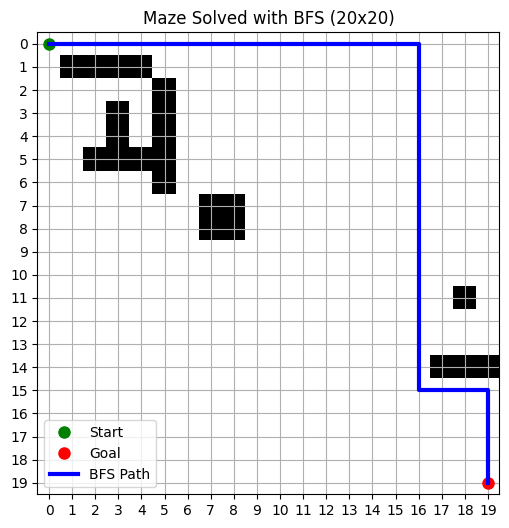

In [6]:
from collections import deque

# --- Task 2: BFS Algorithm ---
def bfs_maze(maze, start, goal):
    rows, cols = maze.shape
    # 4 possible directions: Up, Right, Down, Left
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)] 
    
    # Initialize queue with the start node and its path
    queue = deque([(start, [start])])
    
    # Keep track of visited nodes to avoid infinite loops
    visited = set()
    visited.add(start)
    
    while queue:
        current_node, path = queue.popleft()
        
        # Check if we have reached the goal
        if current_node == goal:
            return path
            
        # Explore all 4 neighbors
        for dr, dc in directions:
            r, c = current_node[0] + dr, current_node[1] + dc
            
            # Check boundaries, walls, and whether it's already visited
            if 0 <= r < rows and 0 <= c < cols and maze[r, c] == 0 and (r, c) not in visited:
                visited.add((r, c))
                queue.append(((r, c), path + [(r, c)]))
                
    # Return None if no path is found
    return None

# Execute BFS and get the path
path = bfs_maze(maze, start, goal)

# --- Plot the Maze and the Path ---
plt.figure(figsize=(6, 6))
plt.imshow(maze, cmap='binary')

plt.xticks(np.arange(maze_size))
plt.yticks(np.arange(maze_size))
plt.grid(True)

# Plot Start and Goal nodes
plt.plot(start[1], start[0], 'go', label='Start', markersize=8)
plt.plot(goal[1], goal[0], 'ro', label='Goal', markersize=8)

# Plot the path if one was found
if path:
    print(f"Path found! Length: {len(path)} steps.")
    path_y = [p[0] for p in path]
    path_x = [p[1] for p in path]
    plt.plot(path_x, path_y, 'b-', linewidth=3, label='BFS Path')
else:
    print("No path found to the goal!")

plt.title("Maze Solved with BFS (20x20)")
plt.legend()
plt.show()


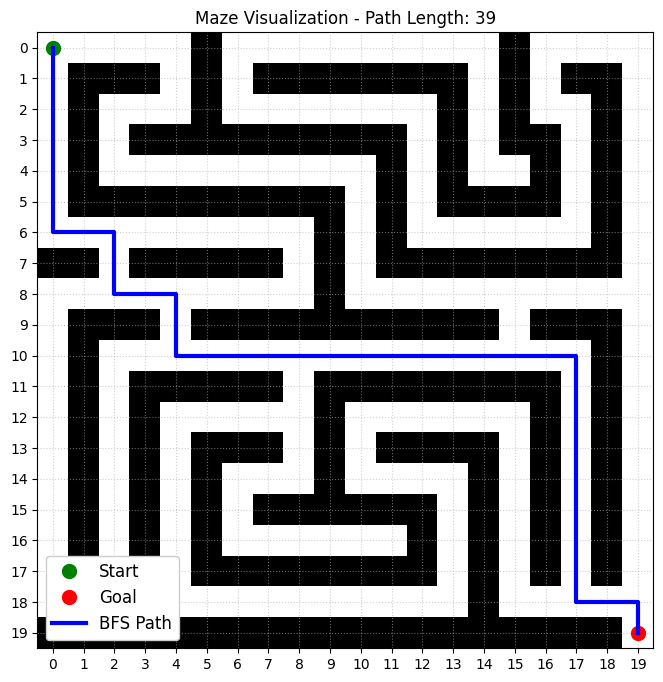

GA reached goal at generation 1


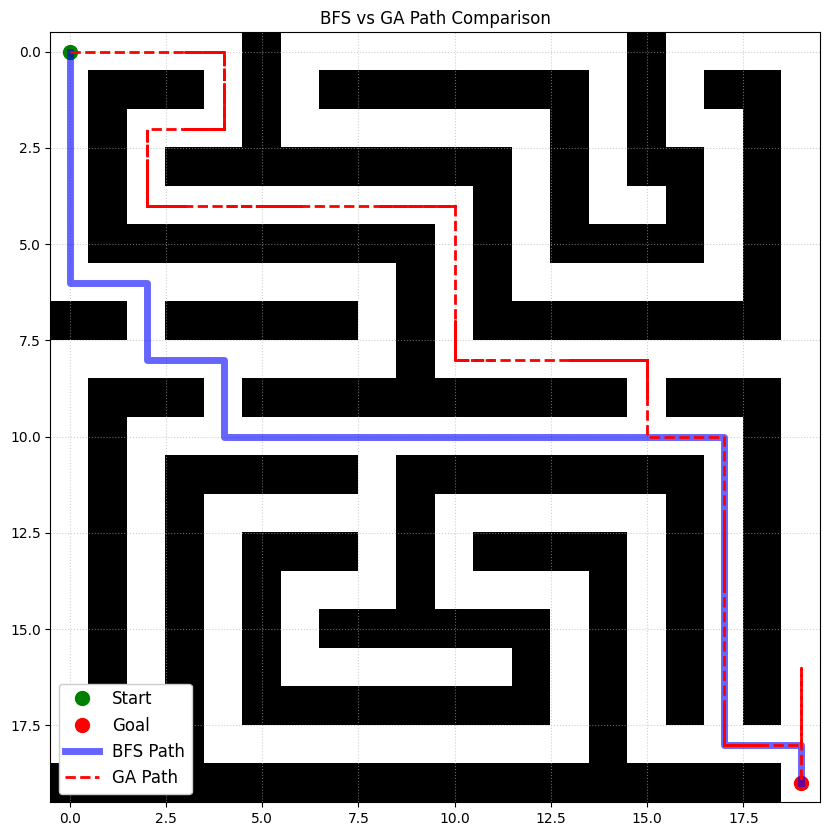

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

MAZE_SIZE = 20
START = (0, 0)
GOAL = (MAZE_SIZE - 1, MAZE_SIZE - 1)

#----------------------
def create_maze(size):
    maze_matrix = [
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
        [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], 
        [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0], 
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0], 
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
    ]
    return np.array(maze_matrix)

#----------------------
def bfs_maze(maze, start, goal):
    rows, cols = maze.shape
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    
    queue = deque([(start, [start])])
    visited = {start}
    
    while queue:
        (r, c), path = queue.popleft()
        
        if (r, c) == goal:
            return path
            
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            if 0 <= nr < rows and 0 <= nc < cols and \
                maze[nr, nc] == 0 and (nr, nc) not in visited:
                visited.add((nr, nc))
                queue.append(((nr, nc), path + [(nr, nc)]))
    return None

#----------------------
def visualize_maze(maze, path=None, title="Maze Visualization"):
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap='binary')
    
    plt.xticks(np.arange(MAZE_SIZE))
    plt.yticks(np.arange(MAZE_SIZE))
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.plot(START[1], START[0], 'go', markersize=10, label='Start')
    plt.plot(GOAL[1], GOAL[0], 'ro', markersize=10, label='Goal')

    if path:
        path_y, path_x = zip(*path)
        plt.plot(path_x, path_y, color='blue', linewidth=3, label='BFS Path')
        plt.title(f"{title} - Path Length: {len(path)}")
    else:
        plt.title(title)
        
    plt.legend(loc='lower left', fontsize=12, framealpha=1.0)
    plt.show()

#----------------------
def simulate_path(maze, start, goal, chromosome):
    r, c = start
    path = [(r, c)]
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    rows, cols = maze.shape
    
    for gene in chromosome:
        dr, dc = directions[gene]
        nr, nc = r + dr, c + dc
        
        if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] == 0:
            r, c = nr, nc
            path.append((r, c))
            
        if (r, c) == goal:
            break
            
    return r, c, path

#----------------------
def calculate_fitness(maze, start, goal, chromosome):
    r, c, path = simulate_path(maze, start, goal, chromosome)
    distance = abs(goal[0] - r) + abs(goal[1] - c)
    
    fitness = 1.0 / (distance + 1)
    
    if distance == 0:
        fitness += 1000 + (1000.0 / len(path))
        
    return fitness

#----------------------
def ga_maze(maze, start, goal, pop_size=150, generations=300, chromosome_length=100):
    population = [[random.randint(0, 3) for _ in range(chromosome_length)] for _ in range(pop_size)]
    
    best_overall_path = None
    best_overall_fitness = -1
    
    for gen in range(generations):
        scored_population = []
        for chrom in population:
            fitness = calculate_fitness(maze, start, goal, chrom)
            scored_population.append((fitness, chrom))
            
            if fitness > best_overall_fitness:
                best_overall_fitness = fitness
                _, _, best_overall_path = simulate_path(maze, start, goal, chrom)
                
        scored_population.sort(key=lambda x: x[0], reverse=True)
        
        if best_overall_fitness > 500:
            print(f"GA reached goal at generation {gen}")
            break
            
        new_population = [scored_population[0][1], scored_population[1][1]]
        
        while len(new_population) < pop_size:
            p1 = random.choice(scored_population[:pop_size//2])[1]
            p2 = random.choice(scored_population[:pop_size//2])[1]
            
            split_point = random.randint(0, chromosome_length - 1)
            child = p1[:split_point] + p2[split_point:]
            
            for i in range(chromosome_length):
                if random.random() < 0.05:
                    child[i] = random.randint(0, 3)
                    
            new_population.append(child)
            
        population = new_population
        
    return best_overall_path

#----------------------
def visualize_comparison(maze, bfs_path, ga_path):
    plt.figure(figsize=(10, 10))
    plt.imshow(maze, cmap='binary')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.plot(START[1], START[0], 'go', markersize=10, label='Start')
    plt.plot(GOAL[1], GOAL[0], 'ro', markersize=10, label='Goal')
    
    if bfs_path:
        by, bx = zip(*bfs_path)
        plt.plot(bx, by, color='blue', linewidth=5, alpha=0.6, label='BFS Path')
        
    if ga_path:
        gy, gx = zip(*ga_path)
        plt.plot(gx, gy, color='red', linewidth=2, linestyle='--', label='GA Path')
        
    plt.title("BFS vs GA Path Comparison")
    
    plt.legend(loc='lower left', fontsize=12, framealpha=1.0)
    plt.show()

#----------------------
maze = create_maze(MAZE_SIZE)

bfs_path = bfs_maze(maze, START, GOAL)
visualize_maze(maze, bfs_path)

ga_path = ga_maze(maze, START, GOAL, pop_size=600, generations=1000, chromosome_length=200)

visualize_comparison(maze, bfs_path, ga_path)
